# High-Value Customer Behavior Simulation for a FinTech Subscription Service

## Section S04 — Data Visualization

This notebook focuses on stakeholder-ready visual comparisons using datasets produced by the reusable package code in `src/`.


In [1]:
from src.notebook_utils import ensure_project_root_on_path, RAW_DATA, CHECKPOINT_DATA, SYNTHETIC_DIR
ensure_project_root_on_path()

import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
sns.set_theme(style='whitegrid')

from src.generators import get_generator
from src.viz import plot_comparison
from src.workflows import create_vip_seed_data, compare_numeric_columns


In [2]:
real_df = create_vip_seed_data(samples=1000, random_state=42)
synth_df = get_generator('specialized').generate(1000, random_state=42)
real_df.head()


,avg_transaction,frequency,credit_score,vip_status
0,55.66,14,737.0,0
1,41.71,11,663.0,0
2,63.73,7,761.0,0
3,38.31,14,772.0,0
4,43.33,14,613.0,0


In [3]:
metrics = compare_numeric_columns(real_df, synth_df)
metrics


,column,real_mean,synthetic_mean,mean_delta,kl_divergence
0,avg_transaction,50.66778,91.81032,41.14254,0.934937
1,frequency,11.80200,12.15500,0.35300,0.051983
2,credit_score,718.28000,719.67600,1.39600,0.047629


In [4]:
plot_path = SYNTHETIC_DIR / 'comparison_avg_transaction.png'
plot_comparison(real_df, synth_df, str(plot_path), column='avg_transaction')
print(f'Plot saved to: {plot_path}')


Plot saved to: /Users/rserban/TST/DEV/PYTHON/WORK/GITHUB_REPOS/GITHUB_KFLOW_DEV/data-services-portfolio/projects/artificial-data-generation/data/synthetic/comparison_avg_transaction.png


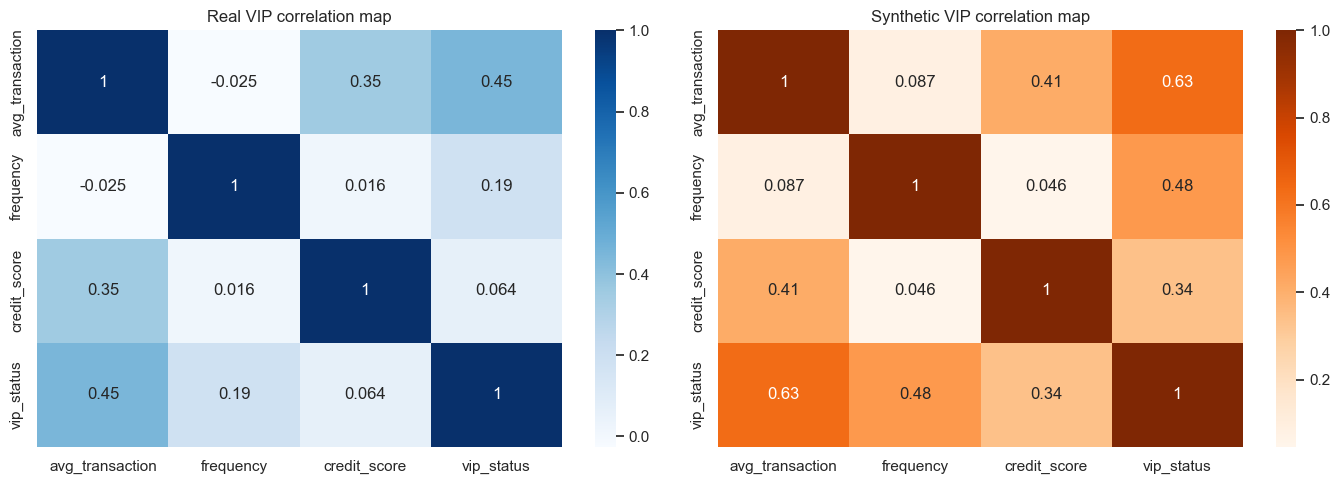

In [5]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
sns.heatmap(real_df[['avg_transaction', 'frequency', 'credit_score', 'vip_status']].corr(), annot=True, cmap='Blues', ax=axes[0])
axes[0].set_title('Real VIP correlation map')
sns.heatmap(synth_df[['avg_transaction', 'frequency', 'credit_score', 'vip_status']].corr(), annot=True, cmap='Oranges', ax=axes[1])
axes[1].set_title('Synthetic VIP correlation map')
plt.tight_layout()
